## 1. Loading the Dataset

In [2]:
# Loading dataset
from datasets import load_dataset
# Loading SMS spam dataset stroed at train
dataset = load_dataset("ucirvine/sms_spam")
dataset = dataset['train']

## 2. Data Exploration

## a) Class Distribution

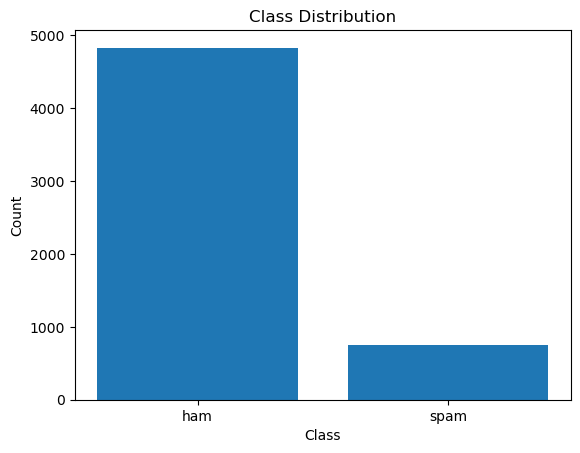

In [5]:
# Data exploration
import matplotlib.pyplot as plt

# Extracting labels
labels = [example['label'] for example in dataset]
# Counting number of spam or ham
label_counts = {label: labels.count(label) for label in set(labels)}

# Ploting distribution
plt.bar(label_counts.keys(), label_counts.values(), tick_label=['ham', 'spam'])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## b) Message Length

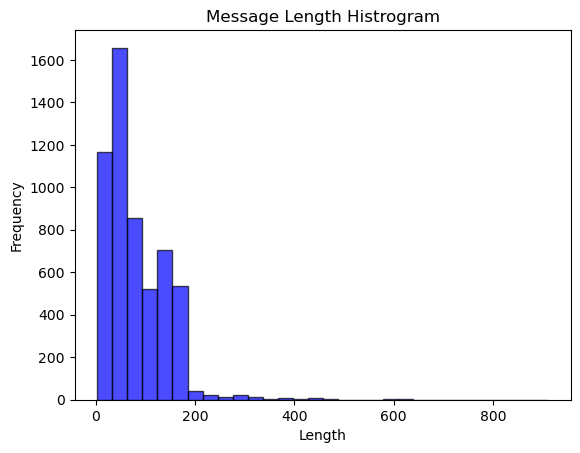

In [7]:
# Calculating message lengths
message_lengths = [len(example['sms']) for example in dataset]

# Ploting histrogram for length
plt.hist(message_lengths, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.title("Message Length Histrogram")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

## c) Most Common Words

In [9]:
# More Data Exploration
from collections import Counter
import re

# converting to lower case and removing non alphabetic characters
def tokenize(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    # spliting text to word
    return text.split()

# separating spam and ham dataset
spam_messages = [example['sms'] for example in dataset if example['label'] == 1]
ham_messages = [example['sms'] for example in dataset if example['label'] == 0]

# Counting tokenized words
spam_words = Counter([word for msg in spam_messages for word in tokenize(msg)])
ham_words = Counter([word for msg in ham_messages for word in tokenize(msg)])

# saving top 10 common words for both lables
spam_common = spam_words.most_common(10)
ham_common = ham_words.most_common(10)

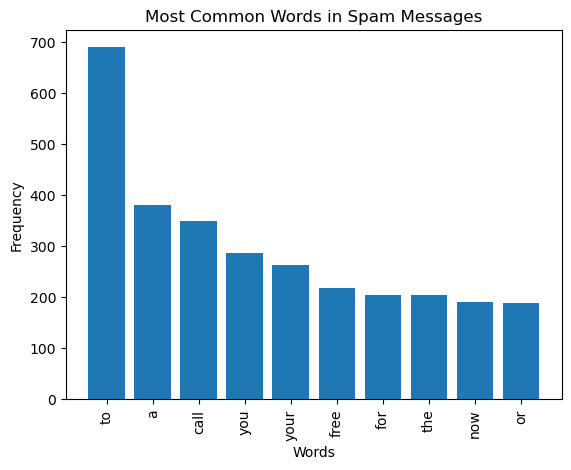

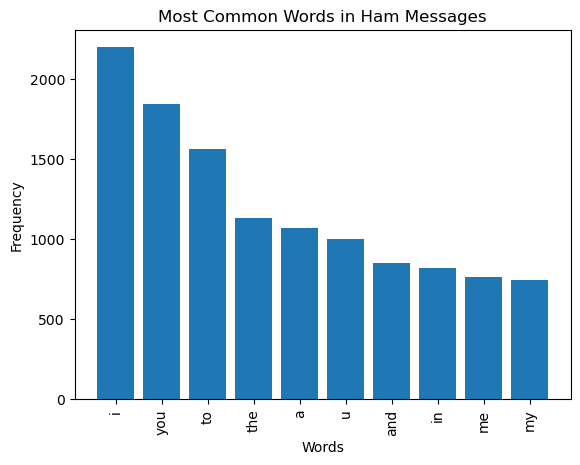

In [10]:
# Plotting common words in spam
spam_words, spam_counts = zip(*spam_common)
plt.bar(spam_words, spam_counts)
plt.title("Most Common Words in Spam Messages")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

# Plotting common words in ham
ham_words, ham_counts = zip(*ham_common)
plt.bar(ham_words, ham_counts)
plt.title("Most Common Words in Ham Messages")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

## 3. Data Cleaning

In [12]:
# Data Cleaning
import pandas as pd
from datasets import Dataset
import re
# data cleaning: lower case, remove non-alphabetic, remove extra space
def clean_text(text):
    # same as the data exploration
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    # removing extra space
    text = re.sub(r'\s+', ' ', text).strip()
    return text
# cleaning dataset using pandas
dataset = dataset.map(lambda x: {'sms': clean_text(x['sms'])})

## 4. Tokenization

In [14]:
from transformers import AutoTokenizer

# Tokenizer for DistilBERT
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
# function for tokenizer
def tokenize_function(example):
    return tokenizer(
        example["sms"],
        # applying padding to gather same length
        padding="max_length",
        truncation=True,  
        max_length=128      
    )

# Final tokenized dataset, applying to every text in dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True)

## 5. Splitting Dataset to Train and Test

In [16]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
import pandas as pd

tokenized_dataset = tokenized_dataset.to_pandas()

# Split dataset into training and testing
train_data, test_data = train_test_split(
    tokenized_dataset,
    test_size=0.2,
    stratify=tokenized_dataset['label']
)

# Converting back to Hugging face
train_dataset = Dataset.from_pandas(train_data)
test_dataset = Dataset.from_pandas(test_data)

dataset_dict = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

dataset_dict['train'].set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
dataset_dict['test'].set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


tokenized_dataset = dataset_dict.map(tokenize_function, batched=True)

# PyTorch
tokenized_dataset['train'].set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_dataset['test'].set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])


Map:   0%|          | 0/4459 [00:00<?, ? examples/s]

Map:   0%|          | 0/1115 [00:00<?, ? examples/s]

## 6. Loading DistilBERT Model

In [18]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2 # binary
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 7. Fine-tuning the Model

In [20]:
from transformers import TrainingArguments

# training arugments
training_args = TrainingArguments(
    output_dir="./distilbert_results", 
    eval_strategy="epoch",  
    learning_rate=2e-5,              
    per_device_train_batch_size=16,  
    num_train_epochs=3,        
    weight_decay=0.01, 
    save_strategy="epoch", 
    metric_for_best_model="accuracy",        
)

In [21]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# setting up metric of interest 
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="binary")
    accuracy = accuracy_score(labels, predictions)
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

In [22]:
from transformers import Trainer
# Training 
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
    compute_metrics=compute_metrics
)

## 8. DistilBERT Model Performance

In [24]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.067087,0.983857,0.958042,0.919463,0.938356
2,0.081600,0.057115,0.988341,0.972222,0.939597,0.955631
3,0.081600,0.061777,0.989238,0.972414,0.946309,0.959184


TrainOutput(global_step=837, training_loss=0.05698198685366905, metrics={'train_runtime': 232.8596, 'train_samples_per_second': 57.447, 'train_steps_per_second': 3.594, 'total_flos': 443004097955328.0, 'train_loss': 0.05698198685366905, 'epoch': 3.0})

In [25]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Loading Dataset SMS Spam
dataset = load_dataset("ucirvine/sms_spam")
# Dividing text and lable dataset
full_sms = dataset['train']['sms']
full_labels = dataset['train']['label']
# Spliting data into train and test 
train_sms, test_sms, y_train, y_test = train_test_split(
    full_sms, full_labels, test_size=0.2, random_state=0, stratify=full_labels)

## 9. Logistic Regression Performance

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Initialize the TF-IDF Vectorizer and transform the data
# Max feasures to 5000 to inhance efficiency
vectorizer = TfidfVectorizer(max_features=5000)
# Transforming data 
X_train = vectorizer.fit_transform(train_sms).toarray()
# for prediction
X_test = vectorizer.transform(test_sms).toarray()

# Training the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

# making prediction from log model
y_pred = logistic_model.predict(X_test)

# Model accuracy and other statistical metrics
logistic_accuracy = accuracy_score(y_test, y_pred)
logistic_classification_report = classification_report(y_test, y_pred)

# Result
print("Accuracy:", logistic_accuracy)
print(logistic_classification_report)

Accuracy: 0.9695067264573991
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       0.99      0.78      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [28]:
from sklearn.metrics import log_loss

# Calculate Log Loss
log_prob = logistic_model.predict_proba(X_test)
log_loss = log_loss(y_test, log_prob)
print("Log Loss:", log_loss)

Log Loss: 0.12235387450759855
